In [1]:
%matplotlib inline


# Using Statsbomb
Getting familiar with Statsbomb data


In [2]:
#importing SBopen class from mplsoccer to open the data
from mplsoccer import Sbopen
# The first thing we have to do is open the data. We use a parser SBopen available in mplsoccer.
parser = Sbopen()


Ronaldo vs Félix — per-90 table


,player,season,minutes,shots_per90,xg_per90,goals_per90
0,Cristiano Ronaldo,Euro 2020,383.0,3.524804,1.142924,1.409922
1,João Félix,Euro 2020,41.0,6.585366,0.290540,0.000000
2,Cristiano Ronaldo,Euro 2024,510.0,4.411765,0.800526,0.882353
3,João Félix,Euro 2024,118.0,3.813559,0.735790,0.000000



Euro 2020 — Cristiano Ronaldo: total shots=15, goals found=6


,match_id,x,y,shot_statsbomb_xg,__goal_reason__
152,3788764,115.9,43.0,0.931034,deep-scan outcome_name
174,3788773,108.1,40.1,0.783500,deep-scan outcome_name
182,3788773,107.9,40.0,0.783500,deep-scan outcome_name
537,3794687,107.1,60.0,0.009358,deep-scan play_pattern_name
1172,3788752,108.0,40.0,0.783500,deep-scan outcome_name
1173,3788752,114.0,44.1,0.796228,deep-scan outcome_name



Euro 2024 — Cristiano Ronaldo: total shots=25, goals found=5


,match_id,x,y,shot_statsbomb_xg,__goal_reason__
94,3942349,118.7,45.1,0.135206,deep-scan play_pattern_name
118,3942349,108.1,40.1,0.783500,deep-scan outcome_name
393,3941020,108.1,40.1,0.783500,deep-scan outcome_name
953,3938644,112.6,28.6,0.058714,deep-scan play_pattern_name
1136,3930174,104.7,54.5,0.030823,deep-scan play_pattern_name


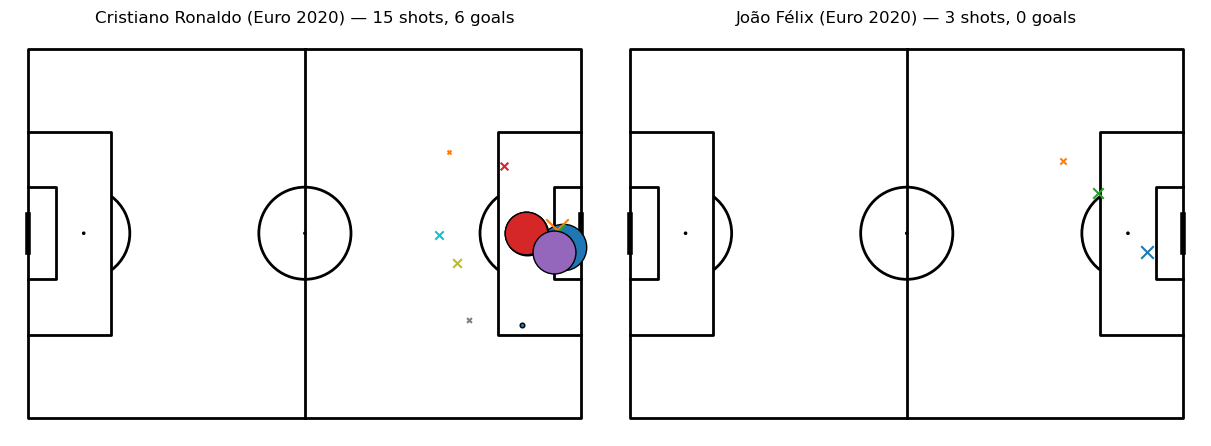

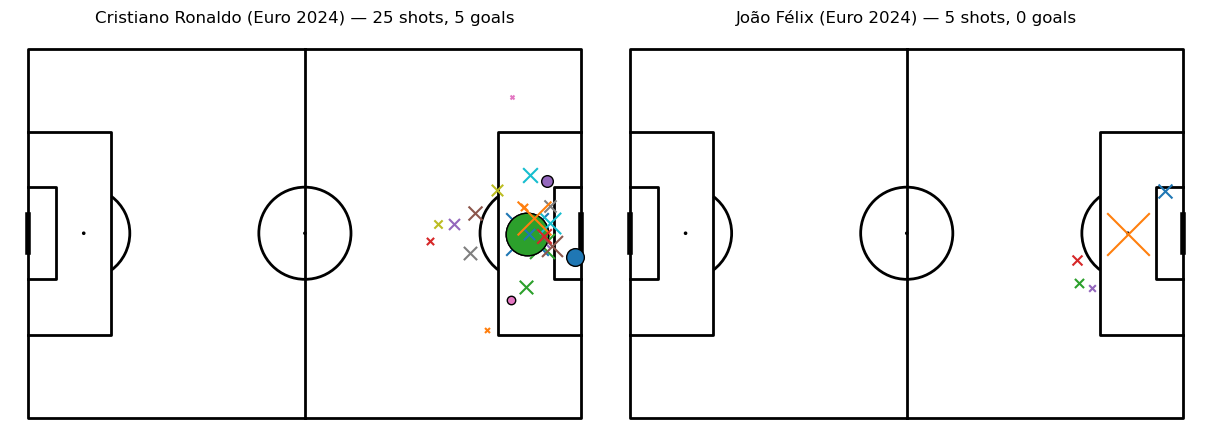

In [3]:
# ===== ONE-CELL "NUKE" SOLUTION: robust goal detection + minutes + figures =====
import pandas as pd, numpy as np, re, ast
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# ---------------- Sbopen helpers ----------------
def ev_df(mid: int) -> pd.DataFrame:
    return parser.event(int(mid))[0]

def get_match_ids(comp_id: int, season_id: int, team=None):
    dfm = parser.match(comp_id, season_id)
    if team is None:
        return dfm["match_id"].astype(int).tolist(), dfm
    mask = (dfm["home_team_name"]==team) | (dfm["away_team_name"]==team)
    return dfm.loc[mask,"match_id"].astype(int).tolist(), dfm

# ---------------- minutes from events (no lineup JSON) ----------------
def match_duration(ev: pd.DataFrame) -> int:
    if "minute" in ev.columns and ev["minute"].notna().any():
        try: return int(np.nanmax(ev["minute"])) + 1
        except: return 90
    return 90

def minutes_from_events(ev: pd.DataFrame):
    dur = match_duration(ev)
    mins = {}
    if "type_name" not in ev.columns: 
        return mins, dur
    subs = ev[ev["type_name"]=="Substitution"] if "type_name" in ev.columns else pd.DataFrame()
    on, off = {}, {}
    rep_col = "substitution_replacement_name" if "substitution_replacement_name" in subs.columns else None
    for _,r in subs.iterrows():
        m = float(r.get("minute",0))
        off_name = r.get("player_name")
        if off_name: off[off_name] = min(off.get(off_name, dur), m)
        if rep_col:
            on_name = r.get(rep_col)
            if on_name: on[on_name] = min(on.get(on_name, m), m)
    ev_players = set(ev["player_name"].dropna().astype(str)) if "player_name" in ev.columns else set()
    starters = ev_players - set(on.keys())
    for p in starters: mins[p] = dur
    for p,m in off.items(): mins[p] = min(mins.get(p, dur), m)
    for p,m in on.items():  mins[p] = mins.get(p, 0.0) + max(0.0, dur - m)
    return mins, dur

# ---------------- robust goal detection ----------------
def _literal_eval_maybe(v):
    # safely parse dict/list stored as string like "{'id':97,'name':'Goal'}"
    if isinstance(v, str):
        s=v.strip()
        if (s.startswith("{") and s.endswith("}")) or (s.startswith("[") and s.endswith("]")):
            try: return ast.literal_eval(s)
            except: return v
    return v

def _search_goal_in_obj(obj):
    """Deep-search any nested object for 'goal' or id==97."""
    if obj is None: return False
    if isinstance(obj, (bool, np.bool_)): return bool(obj)  # if some feeds have is_goal True
    if isinstance(obj, (int, np.integer)): return int(obj)==97
    if isinstance(obj, (float, np.floating)): 
        return False if np.isnan(obj) else int(obj)==97
    if isinstance(obj, str):
        return "goal" in obj.lower() or obj.strip()=="97"
    if isinstance(obj, dict):
        # common StatsBomb: {'outcome':{'id':97,'name':'Goal'}, ...}
        if any(_search_goal_in_obj(v) for v in obj.values()): return True
        return False
    if isinstance(obj, (list, tuple)):
        return any(_search_goal_in_obj(v) for v in obj)
    return False

def is_goal_row(row):
    """
    Decide if a Shot row is a goal.
    1) Look in obvious columns (outcome, shot_outcome_name, shot, is_goal*, result*).
    2) If still unknown, deep-scan ALL object-like columns (including JSON-like strings).
    3) Last resort: use end_location heuristic (ball ends in goalmouth).
    Returns (bool, reason).
    """
    reason = None
    # 1) obvious candidate columns
    candidates = [c for c in row.index if re.search(r"(outcome|is_?goal|result|shot.*outcome)$", str(c), re.I)]
    for c in candidates:
        v = _literal_eval_maybe(row[c])
        if _search_goal_in_obj(v):
            return True, f"matched {c}"
    # 'shot' column (nested dict for many feeds)
    if "shot" in row.index:
        v = _literal_eval_maybe(row["shot"])
        if _search_goal_in_obj(v): 
            return True, "matched shot dict"

    # 2) deep-scan all object-like columns
    for c in row.index:
        v = row[c]
        if isinstance(v, (dict, list, tuple, str)):
            v = _literal_eval_maybe(v)
            if _search_goal_in_obj(v):
                return True, f"deep-scan {c}"

    # 3) end_location heuristic (StatsBomb: goalmouth around x≈120, y≈40)
    # try typical fields: shot_end_location / end_location / shot_end_location_x etc.
    end_fields = [k for k in row.index if re.search(r"(end_?location)", str(k), re.I)]
    hit = False
    for ef in end_fields:
        v = _literal_eval_maybe(row[ef])
        if isinstance(v,(list,tuple)) and len(v)>=2:
            ex,ey = v[0], v[1]
            if isinstance(ex,(int,float)) and isinstance(ey,(int,float)):
                if ex>=119 and 36<=ey<=44:  # inside goal mouth
                    hit = True
                    reason = f"end_location≈goal ({ef})"
                    break
    if hit: return True, reason

    return False, "no signal"

def collect_comp(comp_id, season_id):
    mids, _ = get_match_ids(comp_id, season_id)
    shot_rows = []
    minutes = {}
    for mid in mids:
        ev = ev_df(mid)
        if ev.empty or "type_name" not in ev.columns: 
            continue
        m_map,_ = minutes_from_events(ev)
        for n,mins in m_map.items():
            minutes[n] = minutes.get(n,0.0)+mins

        sh = ev[ev["type_name"]=="Shot"].copy()
        if sh.empty: 
            continue

        # coords & xG
        if not {"x","y"}.issubset(sh.columns) and "location" in sh.columns:
            sh["x"] = sh["location"].apply(lambda loc: loc[0] if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)
            sh["y"] = sh["location"].apply(lambda loc: loc[1] if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)
        if "shot_statsbomb_xg" not in sh.columns:
            sh["shot_statsbomb_xg"] = sh.get("shot_xg", np.nan)

        # goal detection
        flags, reasons = [], []
        for _,r in sh.iterrows():
            g, why = is_goal_row(r)
            flags.append(g); reasons.append(why)
        sh["__is_goal__"] = flags
        sh["__goal_reason__"] = reasons

        sh["match_id"] = int(mid)
        shot_rows.append(sh)

    shots = pd.concat(shot_rows, ignore_index=True) if shot_rows else pd.DataFrame()
    if shots.empty:
        agg = pd.DataFrame(columns=["player_name","shots","goals","xg","minutes","shots_per90","xg_per90","goals_per90"])
        return shots, agg

    # aggregate
    agg = (shots.groupby("player_name", dropna=False)
                 .agg(shots=("x","count"),
                      goals=("__is_goal__", lambda s: int(np.sum(s))),
                      xg=("shot_statsbomb_xg","sum"))
                 .reset_index())
    agg["minutes"] = agg["player_name"].map(minutes).fillna(0.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        agg["shots_per90"] = np.where(agg["minutes"]>0, agg["shots"]*90/agg["minutes"], np.nan)
        agg["xg_per90"]    = np.where(agg["minutes"]>0, agg["xg"]*90/agg["minutes"], np.nan)
        agg["goals_per90"] = np.where(agg["minutes"]>0, agg["goals"]*90/agg["minutes"], np.nan)
    return shots, agg

# ---------------- run for Euro 2020 & Euro 2024 ----------------
shots20, players20 = collect_comp(55, 43)
shots24, players24 = collect_comp(55, 282)

def pick(df, q, season):
    m = df[df["player_name"].astype(str).str.contains(q, case=False, na=False)]
    if m.empty:
        return {"player": q, "season": season, "minutes": 0.0, "shots_per90": np.nan, "xg_per90": np.nan, "goals_per90": np.nan}
    r = m.sort_values("minutes", ascending=False).iloc[0]
    return {"player": q, "season": season,
            "minutes": float(r["minutes"]),
            "shots_per90": float(r["shots_per90"]),
            "xg_per90": float(r["xg_per90"]),
            "goals_per90": float(r["goals_per90"])}

rows = [
    pick(players20, "Cristiano Ronaldo", "Euro 2020"),
    pick(players20, "João Félix", "Euro 2020"),
    pick(players24, "Cristiano Ronaldo", "Euro 2024"),
    pick(players24, "João Félix", "Euro 2024"),
]
table = pd.DataFrame(rows)
print("Ronaldo vs Félix — per-90 table")
display(table)

# ---------------- diagnostics: show Ronaldo goals & why they were detected ----------------
def diag(shots, who, label):
    s = shots[shots["player_name"].astype(str).str.contains(who, case=False, na=False)]
    goals = s[s["__is_goal__"]==True]
    print(f"\n{label}: total shots={len(s)}, goals found={len(goals)}")
    if len(goals)==0:
        # show a few raw columns to see what's there
        cols_to_show = [c for c in s.columns if re.search(r"(shot|outcome|result|end_?location|goal)", str(c), re.I)]
        display(s[cols_to_show].head(5))
    else:
        display(goals[["match_id","x","y","shot_statsbomb_xg","__goal_reason__"]].head(10))

diag(shots20, "Ronaldo", "Euro 2020 — Cristiano Ronaldo")
diag(shots24, "Ronaldo", "Euro 2024 — Cristiano Ronaldo")

# ---------------- 2 shot-map figures (consistent colors) ----------------
def plot_shotmap(ax, df, name, team="Portugal", title_suffix=""):
    pitch = Pitch(pitch_type="statsbomb", line_color="black"); pitch.draw(ax=ax)
    s = df[df["player_name"].astype(str).str.contains(name, case=False, na=False)]
    if "team_name" in s.columns:
        s = s[s["team_name"]==team]
    for _,r in s.iterrows():
        size = 1200 * float(r.get("shot_statsbomb_xg",0.05))
        if r.get("__is_goal__"): pitch.scatter(r["x"], r["y"], s=size, marker="o", edgecolors="black", ax=ax)  # goal
        else:                    pitch.scatter(r["x"], r["y"], s=size, marker="x", ax=ax)                      # not goal
    ax.set_title(f"{name}{title_suffix} — {len(s)} shots, {int(s['__is_goal__'].sum())} goals")

fig, ax = plt.subplots(1,2, figsize=(12,6), constrained_layout=True)
plot_shotmap(ax[0], shots20, "Cristiano Ronaldo", "Portugal", " (Euro 2020)")
plot_shotmap(ax[1], shots20, "João Félix", "Portugal", " (Euro 2020)")
plt.show()

fig, ax = plt.subplots(1,2, figsize=(12,6), constrained_layout=True)
plot_shotmap(ax[0], shots24, "Cristiano Ronaldo", "Portugal", " (Euro 2024)")
plot_shotmap(ax[1], shots24, "João Félix", "Portugal", " (Euro 2024)")
plt.show()


## Competition data
Using method *competition* of the parser we can explore competitions to find the competition we are interested in.
The most important information for us is in the *competition_id* (id of competition) and *season_id*.
The first one is the key in Statsbomb database of a competition, the second one of a season 
of this competition (for example WC 2018 would have a different *season_id* than WC 2014, but the same *competition_id*).



In [4]:
#opening data using competition method
df_competition = parser.competition()
#structure of data
df_competition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   competition_id             75 non-null     int64 
 1   season_id                  75 non-null     int64 
 2   country_name               75 non-null     object
 3   competition_name           75 non-null     object
 4   competition_gender         75 non-null     object
 5   competition_youth          75 non-null     bool  
 6   competition_international  75 non-null     bool  
 7   season_name                75 non-null     object
 8   match_updated              75 non-null     object
 9   match_updated_360          57 non-null     object
 10  match_available_360        11 non-null     object
 11  match_available            75 non-null     object
dtypes: bool(2), int64(2), object(8)
memory usage: 6.1+ KB


## Match data
Using method *match* of the parser we can explore matches of a competition to find the match we are interested in.
To open it we need to know the *competition_id* (id of competition) and *season_id*.
We know that for Women World Cup *competition_id* is 72 and *season_id* is 30
From this dataframe for us the most important imformation is provided in *match_id*, 
*home_team_id* and *home_team_name* and adequately *away_team_id* and *away_team_name*.



In [5]:
#opening data using match method
df_match = parser.match(competition_id=72, season_id=30)
#structure of data
df_match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   match_id                         52 non-null     int64         
 1   match_date                       52 non-null     datetime64[ns]
 2   kick_off                         52 non-null     datetime64[ns]
 3   home_score                       52 non-null     int64         
 4   away_score                       52 non-null     int64         
 5   match_status                     52 non-null     object        
 6   match_status_360                 52 non-null     object        
 7   last_updated                     52 non-null     datetime64[ns]
 8   last_updated_360                 52 non-null     datetime64[ns]
 9   match_week                       52 non-null     int64         
 10  competition_id                   52 non-null     int64         


## Lineup data
To check the lineups we use the *lineup* method. We do it for England Sweden WWC 2019 game - *game_id* is 69301 
- you can check that in the df_match. In this dataframe you will find all players who played in this game, their teams 
and jersey numbers
COMMENTED OUT BECAUSE OF CHANGE OF DATA FORMAT.



In [6]:
#opening data using match method
#df_lineup = parser.lineup(69301)
#structure of data
#df_lineup.info()

## Event data
The Statsbomb data that we will use the most during the course is event data. 
Knowing *game_id* you can open all the events that occured on the pitch
In the event dataframe you will find events with additional information, we will mostly use this dataframe.
Tactics dataframe provides information about player position on the pitch. 'Related' dataframe provides information
on events that were related to each other - for example ball pass and pressure applied. *df_freeze* consists of freezed
frames with player position in the moment of shots. We will learn more about tracking data later in the course.
Below, an example of event data is presented.



In [7]:
#opening data
df_event, df_related, df_freeze, df_tactics = parser.event(69301)
#if you want only event data you can use 
#df_event = parser.event(69301)[0]
#structure of data
df_event.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 73 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              3289 non-null   object 
 1   index                           3289 non-null   int64  
 2   period                          3289 non-null   int64  
 3   timestamp                       3289 non-null   object 
 4   minute                          3289 non-null   int64  
 5   second                          3289 non-null   int64  
 6   possession                      3289 non-null   int64  
 7   duration                        2457 non-null   float64
 8   match_id                        3289 non-null   int64  
 9   type_id                         3289 non-null   int64  
 10  type_name                       3289 non-null   object 
 11  possession_team_id              3289 non-null   int64  
 12  possession_team_name            32

## 360 data
Statsbomb offers 360 data which track not only location of an event but also players' location. To open them we need
an id of game. Later, we will also need id of the event. In the *df_frame* we find information on players' position (but only if teammate, not all information)
and in *df_visible* it is provided which part of the pitch was tracked during an event.



In [8]:
df_frame, df_visible = parser.frame(3788741)

# exploring the data
df_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45737 entries, 0 to 45736
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   teammate  45737 non-null  bool   
 1   actor     45737 non-null  bool   
 2   keeper    45737 non-null  bool   
 3   match_id  45737 non-null  int64  
 4   id        45737 non-null  object 
 5   x         45737 non-null  float64
 6   y         45737 non-null  float64
dtypes: bool(3), float64(2), int64(1), object(1)
memory usage: 1.5+ MB


## Before you start
Run these lines in Spyder/Jupyter notebook and explore dataframes 
to get more familiar before you start working on the course.


lets compare ronaldo with other forwards


# === ONE-CELL ANALYSIS: Fig1 (2020 shot maps) + Fig2 (2024 npxG vs Pressures vs Touches in Box) ===
import pandas as pd, numpy as np, re, ast
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# --------- BASIC HELPERS ----------
def ev_df(mid: int) -> pd.DataFrame:
    return parser.event(int(mid))[0]

def get_match_ids(comp_id: int, season_id: int, team=None):
    dfm = parser.match(comp_id, season_id)
    if team is None:
        return dfm["match_id"].astype(int).tolist()
    mask = (dfm["home_team_name"]==team) | (dfm["away_team_name"]==team)
    return dfm.loc[mask,"match_id"].astype(int).tolist()

def match_duration(ev: pd.DataFrame) -> int:
    if "minute" in ev.columns and ev["minute"].notna().any():
        try: return int(np.nanmax(ev["minute"])) + 1
        except: return 90
    return 90

def minutes_from_events(ev: pd.DataFrame):
    dur = match_duration(ev)
    mins = {}
    if "type_name" not in ev.columns: 
        return mins, dur
    subs = ev[ev["type_name"]=="Substitution"] if "type_name" in ev.columns else pd.DataFrame()
    on, off = {}, {}
    rep_col = "substitution_replacement_name" if "substitution_replacement_name" in subs.columns else None
    for _,r in subs.iterrows():
        m = float(r.get("minute",0))
        off_name = r.get("player_name")
        if off_name: off[off_name] = min(off.get(off_name, dur), m)
        if rep_col:
            on_name = r.get(rep_col)
            if on_name: on[on_name] = min(on.get(on_name, m), m)
    ev_players = set(ev["player_name"].dropna().astype(str)) if "player_name" in ev.columns else set()
    starters = ev_players - set(on.keys())
    for p in starters: mins[p] = dur
    for p,m in off.items(): mins[p] = min(mins.get(p, dur), m)
    for p,m in on.items():  mins[p] = mins.get(p, 0.0) + max(0.0, dur - m)
    return mins, dur

# --------- ROBUST GOAL + PENALTY DETECTION ----------
def _literal_eval_maybe(v):
    if isinstance(v, str):
        s=v.strip()
        if (s.startswith("{") and s.endswith("}")) or (s.startswith("[") and s.endswith("]")):
            try: return ast.literal_eval(s)
            except: return v
    return v

def _search_goal(obj):
    """True if any nested dict/list/str/id is 'Goal' (name) or id==97."""
    if obj is None: return False
    if isinstance(obj, (bool, np.bool_)): return bool(obj)
    if isinstance(obj, (int, np.integer)): return int(obj)==97
    if isinstance(obj, (float, np.floating)): return False if np.isnan(obj) else int(obj)==97
    if isinstance(obj, str): return ("goal" in obj.lower()) or (obj.strip()=="97")
    if isinstance(obj, dict): return any(_search_goal(v) for v in obj.values())
    if isinstance(obj, (list, tuple)): return any(_search_goal(v) for v in obj)
    return False

def _search_penalty(obj):
    """True if nested structure indicates penalty (name 'Penalty' or similar)."""
    if obj is None: return False
    if isinstance(obj, str): return "penalty" in obj.lower()
    if isinstance(obj, dict):
        # typical: shot: {type:{id:..., name:'Penalty'}}
        if any(_search_penalty(v) for v in obj.values()): return True
    if isinstance(obj, (list, tuple)): return any(_search_penalty(v) for v in obj)
    return False

def is_goal_row(row):
    # 1) obvious columns
    candidates = [c for c in row.index if re.search(r"(outcome|is_?goal|result|shot.*outcome)$", str(c), re.I)]
    for c in candidates:
        v = _literal_eval_maybe(row[c])
        if _search_goal(v): return True
    # shot dict
    if "shot" in row.index:
        v = _literal_eval_maybe(row["shot"])
        if _search_goal(v): return True
    # 2) end_location heuristic
    end_fields = [k for k in row.index if re.search(r"(end_?location)", str(k), re.I)]
    for ef in end_fields:
        v = _literal_eval_maybe(row[ef])
        if isinstance(v,(list,tuple)) and len(v)>=2:
            ex,ey = v[0], v[1]
            if isinstance(ex,(int,float)) and isinstance(ey,(int,float)):
                if ex>=119 and 36<=ey<=44:  # mouth of goal in StatsBomb coords
                    return True
    return False

def is_penalty_row(row):
    # look in type columns
    candidates = [c for c in row.index if re.search(r"(shot.*type|type.*shot)", str(c), re.I)]
    for c in candidates:
        v = _literal_eval_maybe(row[c])
        if _search_penalty(v): return True
    # often inside 'shot' dict
    if "shot" in row.index:
        v = _literal_eval_maybe(row["shot"])
        if _search_penalty(v): return True
    # sometimes a flat 'shot_type_name'
    if "shot_type_name" in row.index and isinstance(row["shot_type_name"], str):
        return "penalty" in row["shot_type_name"].lower()
    return False

# --------- BOX CHECK ----------
def in_pen_box(x, y):
    # Attacking penalty area (towards x=120): x >= 102 and 18 <= y <= 62
    return (x is not None) and (y is not None) and (x >= 102) and (18 <= y <= 62)

# --------- GATHER TOURNAMENT METRICS (for a given team) ----------
def gather_team_metrics(comp_id, season_id, team_name, players_for_shotmap=None):
    mids = get_match_ids(comp_id, season_id, team=team_name)
    # aggregates
    minutes_total = {}
    pressures = {}
    touches_box = {}
    # store shots for shotmaps for selected players
    shot_rows = []

    for mid in mids:
        ev = ev_df(mid)
        if ev.empty or "type_name" not in ev.columns: 
            continue

        # minutes
        m_map, _ = minutes_from_events(ev)
        for n,mins in m_map.items():
            minutes_total[n] = minutes_total.get(n,0.0)+mins

        # keep only this team for counting
        ev_team = ev[ev["team_name"]==team_name].copy()

        # pressures
        prs = ev_team[ev_team["type_name"]=="Pressure"]
        if not prs.empty:
            cnt = prs.groupby("player_name").size()
            for n,v in cnt.items():
                pressures[n] = pressures.get(n,0)+int(v)

        # touches in box: any event with location/x,y inside box
        if ("x" in ev_team.columns and "y" in ev_team.columns):
            loc_df = ev_team[["player_name","x","y"]].dropna()
            loc_df = loc_df[loc_df.apply(lambda r: in_pen_box(float(r["x"]), float(r["y"])), axis=1)]
        elif "location" in ev_team.columns:
            loc_df = ev_team[["player_name","location"]].dropna()
            loc_df["x"] = loc_df["location"].apply(lambda loc: float(loc[0]) if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)
            loc_df["y"] = loc_df["location"].apply(lambda loc: float(loc[1]) if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)
            loc_df = loc_df.dropna(subset=["x","y"])
            loc_df = loc_df[loc_df.apply(lambda r: in_pen_box(r["x"], r["y"]), axis=1)]
        else:
            loc_df = pd.DataFrame(columns=["player_name"])

        if not loc_df.empty:
            tcnt = loc_df.groupby("player_name").size()
            for n,v in tcnt.items():
                touches_box[n] = touches_box.get(n,0)+int(v)

        # shots (for shot maps & xG)
        sh = ev_team[ev_team["type_name"]=="Shot"].copy()
        if not sh.empty:
            # coords & xG
            if not {"x","y"}.issubset(sh.columns) and "location" in sh.columns:
                sh["x"] = sh["location"].apply(lambda loc: loc[0] if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)
                sh["y"] = sh["location"].apply(lambda loc: loc[1] if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)
            if "shot_statsbomb_xg" not in sh.columns:
                sh["shot_statsbomb_xg"] = sh.get("shot_xg", np.nan)

            # flags
            goals = []; pens = []
            for _,r in sh.iterrows():
                goals.append(is_goal_row(r))
                pens.append(is_penalty_row(r))
            sh["__is_goal__"] = goals
            sh["__is_pen__"]  = pens
            sh["match_id"]    = int(mid)

            # store only players of interest for shotmap (if provided)
            if players_for_shotmap:
                m = pd.Series(False, index=sh.index)
                for nm in players_for_shotmap:
                    m |= sh["player_name"].astype(str).str.contains(nm, case=False, na=False)
                shot_rows.append(sh[m][["player_name","x","y","shot_statsbomb_xg","__is_goal__","__is_pen__","match_id"]])
            else:
                shot_rows.append(sh[["player_name","x","y","shot_statsbomb_xg","__is_goal__","__is_pen__","match_id"]])

    shots = pd.concat(shot_rows, ignore_index=True) if shot_rows else pd.DataFrame(columns=["player_name","x","y","shot_statsbomb_xg","__is_goal__","__is_pen__","match_id"])

    # build per-player stats from shots
    stats = []
    for name in set(list(minutes_total.keys()) + list(pressures.keys()) + list(touches_box.keys()) + shots["player_name"].astype(str).unique().tolist()):
        if not isinstance(name, str) or name is None: 
            continue
        s = shots[shots["player_name"].astype(str)==name]
        shots_n   = len(s)
        goals_n   = int(s["__is_goal__"].sum()) if not s.empty else 0
        xg_sum    = float(s["shot_statsbomb_xg"].sum()) if not s.empty else 0.0
        npxg_sum  = float(s.loc[~s["__is_pen__"], "shot_statsbomb_xg"].sum()) if not s.empty else 0.0
        mins      = float(minutes_total.get(name, 0.0))
        prs       = int(pressures.get(name, 0))
        tib       = int(touches_box.get(name, 0))
        # per-90
        if mins > 0:
            shots_p90 = shots_n*90/mins
            xg_p90    = xg_sum*90/mins
            npxg_p90  = npxg_sum*90/mins
            goals_p90 = goals_n*90/mins
            prs_p90   = prs*90/mins
            tib_p90   = tib*90/mins
        else:
            shots_p90 = xg_p90 = npxg_p90 = goals_p90 = prs_p90 = tib_p90 = np.nan
        stats.append({
            "player_name": name, "minutes": mins,
            "shots": shots_n, "goals": goals_n, "xg": xg_sum, "npxg": npxg_sum,
            "shots_per90": shots_p90, "xg_per90": xg_p90, "npxg_per90": npxg_p90, "goals_per90": goals_p90,
            "pressures": prs, "pressures_per90": prs_p90,
            "touches_in_box": tib, "touches_in_box_per90": tib_p90
        })
    stats_df = pd.DataFrame(stats)
    return shots, stats_df

# --------- FIGURE 1: EURO 2020 — Ronaldo vs Diogo Jota (shot maps) ----------
COMP_ID, TEAM = 55, "Portugal"
SEASON_2020, SEASON_2024 = 43, 282

players_2020_for_shotmap = ["Cristiano Ronaldo", "Diogo Jota"]
shots20, stats20 = gather_team_metrics(COMP_ID, SEASON_2020, TEAM, players_for_shotmap=players_2020_for_shotmap)

def plot_shotmap_side_by_side(shots_df, left_name, right_name, title):
    fig, ax = plt.subplots(1,2, figsize=(12,6), constrained_layout=True)
    pitch = Pitch(pitch_type="statsbomb", line_color="black")
    for i,name in enumerate([left_name, right_name]):
        pitch.draw(ax=ax[i])
        sdf = shots_df[shots_df["player_name"].astype(str).str.contains(name, case=False, na=False)].copy()
        goals = int(sdf["__is_goal__"].sum()) if not sdf.empty else 0
        for _,r in sdf.iterrows():
            size = 1200 * float(r.get("shot_statsbomb_xg", 0.05))
            if bool(r.get("__is_goal__", False)):
                pitch.scatter(r["x"], r["y"], s=size, marker="o", edgecolors="black", ax=ax[i])
            else:
                pitch.scatter(r["x"], r["y"], s=size, marker="x", ax=ax[i])
        ax[i].set_title(f"{name} — {len(sdf)} shots, {goals} goals")
    fig.suptitle(title, fontsize=14)
    plt.show()

plot_shotmap_side_by_side(shots20, "Cristiano Ronaldo", "Diogo Jota",
                          "Portugal (EURO 2020) — Shot maps (● goal, × other; size≈xG)")

# --------- FIGURE 2: EURO 2024 — npxG/90 vs Pressures/90; size = Touches in Box/90 ----------
players_2024_compare = ["Cristiano Ronaldo", "Bruno Fernandes", "Bernardo Silva", "Gonçalo Ramos"]
shots24, stats24 = gather_team_metrics(COMP_ID, SEASON_2024, TEAM, players_for_shotmap=players_2024_compare)

tbl24 = (stats24[stats24["player_name"].astype(str).str.contains("|".join(players_2024_compare), case=False, na=False)]
         .loc[:, ["player_name","minutes","npxg_per90","pressures_per90","touches_in_box_per90"]]
         .copy())

# scatter
fig, ax = plt.subplots(figsize=(8,6))
x = tbl24["npxg_per90"].astype(float)
y = tbl24["pressures_per90"].astype(float)
s = 800 * (tbl24["touches_in_box_per90"].astype(float) / (tbl24["touches_in_box_per90"].max() or 1.0))

ax.scatter(x, y, s=s)

# label with surnames
def surname(full):
    parts = str(full).split()
    return parts[-1] if parts else full

for _, row in tbl24.iterrows():
    ax.text(row["npxg_per90"], row["pressures_per90"], "  " + surname(row["player_name"]), va="center")

ax.set_xlabel("Non-penalty xG per 90")
ax.set_ylabel("Pressures per 90")
ax.set_title("Portugal (EURO 2024) — Role contrast: npxG/90 vs Pressures/90 (size = Touches in Box/90)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("EURO 2024 comparison table (these four):")
display(tbl24.sort_values("npxg_per90", ascending=False))


#lets change tactics lets compare ronaldo with himself and other players playing same position

In [11]:
# ==== HELPERS: minutes, robust goal/penalty parsing, tournament metrics, optional positions ====
import pandas as pd, numpy as np, re, ast
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# ---------- Sbopen wrappers ----------
def ev_df(mid: int) -> pd.DataFrame:
    return parser.event(int(mid))[0]

def ev_tactics(mid: int) -> pd.DataFrame:
    # parser.event returns (events, related, freeze, tactics); tactics may be empty in some feeds
    try:
        return parser.event(int(mid))[3]
    except Exception:
        return pd.DataFrame()

def match_ids(comp_id: int, season_id: int) -> list[int]:
    return parser.match(comp_id, season_id)["match_id"].astype(int).tolist()

# ---------- minutes from events only ----------
def match_duration(ev: pd.DataFrame) -> int:
    if "minute" in ev.columns and ev["minute"].notna().any():
        try:  return int(np.nanmax(ev["minute"])) + 1
        except: return 90
    return 90

def minutes_from_events(ev: pd.DataFrame):
    dur = match_duration(ev)
    mins = {}
    if "type_name" not in ev.columns: 
        return mins, dur
    subs = ev[ev["type_name"]=="Substitution"] if "type_name" in ev.columns else pd.DataFrame()
    on, off = {}, {}
    rep_col = "substitution_replacement_name" if "substitution_replacement_name" in subs.columns else None
    for _,r in subs.iterrows():
        m = float(r.get("minute",0))
        off_name = r.get("player_name")
        if off_name: off[off_name] = min(off.get(off_name, dur), m)
        if rep_col:
            on_name = r.get(rep_col)
            if on_name: on[on_name] = min(on.get(on_name, m), m)
    ev_players = set(ev["player_name"].dropna().astype(str)) if "player_name" in ev.columns else set()
    starters = ev_players - set(on.keys())
    for p in starters: mins[p] = dur
    for p,m in off.items(): mins[p] = min(mins.get(p, dur), m)
    for p,m in on.items():  mins[p] = mins.get(p, 0.0) + max(0.0, dur - m)
    return mins, dur

# ---------- robust nested parsing ----------
def _literal_eval_maybe(v):
    if isinstance(v, str):
        s=v.strip()
        if (s.startswith("{") and s.endswith("}")) or (s.startswith("[") and s.endswith("]")):
            try: return ast.literal_eval(s)
            except: return v
    return v

def _search_goal(obj):
    """True if nested dict/list/str/id signals 'Goal' (or id 97)."""
    if obj is None: return False
    if isinstance(obj, (bool, np.bool_)): return bool(obj)
    if isinstance(obj, (int, np.integer)): return int(obj)==97
    if isinstance(obj, (float, np.floating)): return False if np.isnan(obj) else int(obj)==97
    if isinstance(obj, str): return ("goal" in obj.lower()) or (obj.strip()=="97")
    if isinstance(obj, dict): return any(_search_goal(v) for v in obj.values())
    if isinstance(obj, (list, tuple)): return any(_search_goal(v) for v in obj)
    return False

def _search_penalty(obj):
    if obj is None: return False
    if isinstance(obj, str): return "penalty" in obj.lower()
    if isinstance(obj, dict): return any(_search_penalty(v) for v in obj.values())
    if isinstance(obj, (list, tuple)): return any(_search_penalty(v) for v in obj)
    return False

def is_goal_row(row):
    # look in common outcome columns
    candidates = [c for c in row.index if re.search(r"(outcome|is_?goal|result|shot.*outcome)$", str(c), re.I)]
    for c in candidates:
        v = _literal_eval_maybe(row[c])
        if _search_goal(v): return True
    # look in 'shot' dict
    if "shot" in row.index:
        v = _literal_eval_maybe(row["shot"])
        if _search_goal(v): return True
    # fallback: end_location in goal mouth (x≈120, y≈40)
    end_fields = [k for k in row.index if re.search(r"(end_?location)", str(k), re.I)]
    for ef in end_fields:
        v = _literal_eval_maybe(row[ef])
        if isinstance(v,(list,tuple)) and len(v)>=2:
            ex,ey = v[0], v[1]
            if isinstance(ex,(int,float)) and isinstance(ey,(int,float)) and (ex>=119) and (36<=ey<=44):
                return True
    return False

def is_penalty_row(row):
    # look for penalty in shot type fields
    candidates = [c for c in row.index if re.search(r"(shot.*type|type.*shot|shot_type_name)$", str(c), re.I)]
    for c in candidates:
        v = _literal_eval_maybe(row[c])
        if _search_penalty(v): return True
    # often inside 'shot' dict
    if "shot" in row.index:
        v = _literal_eval_maybe(row["shot"])
        if _search_penalty(v): return True
    return False

def in_pen_box(x, y):
    # Attacking penalty area (towards x=120): x >= 102 and 18 <= y <= 62
    try:
        return (x is not None) and (y is not None) and (float(x) >= 102) and (18 <= float(y) <= 62)
    except Exception:
        return False

# ---------- tournament metrics across ALL teams ----------
def tournament_metrics(comp_id, season_id):
    mids = match_ids(comp_id, season_id)
    minutes_total = {}
    pressures = {}
    touches_box = {}
    shots_rows = []
    last_team_for_player = {}

    for mid in mids:
        ev = ev_df(mid)
        if ev.empty or "type_name" not in ev.columns: 
            continue

        # minutes
        m_map, _ = minutes_from_events(ev)
        for n,mins in m_map.items():
            minutes_total[n] = minutes_total.get(n,0.0)+mins

        # record last seen team for label
        if "team_name" in ev.columns and "player_name" in ev.columns:
            tmp = ev[["team_name","player_name"]].dropna().tail(2000)  # sample
            for _, r in tmp.iterrows():
                last_team_for_player[str(r["player_name"])] = str(r["team_name"])

        # pressures (all teams)
        prs = ev[ev["type_name"]=="Pressure"]
        if not prs.empty:
            cnt = prs.groupby("player_name").size()
            for n,v in cnt.items():
                pressures[n] = pressures.get(n,0)+int(v)

        # touches in box (any event inside box)
        loc = ev.copy()
        # normalize to x,y if needed
        if "x" not in loc.columns or "y" not in loc.columns:
            if "location" in loc.columns:
                loc["x"] = loc["location"].apply(lambda L: L[0] if isinstance(L,(list,tuple)) and len(L)>=2 else np.nan)
                loc["y"] = loc["location"].apply(lambda L: L[1] if isinstance(L,(list,tuple)) and len(L)>=2 else np.nan)
        if {"player_name","x","y"}.issubset(loc.columns):
            box_df = loc.dropna(subset=["player_name","x","y"])
            box_df = box_df[box_df.apply(lambda r: in_pen_box(r["x"], r["y"]), axis=1)]
            if not box_df.empty:
                tcnt = box_df.groupby("player_name").size()
                for n,v in tcnt.items():
                    touches_box[n] = touches_box.get(n,0)+int(v)

        # shots
        sh = ev[ev["type_name"]=="Shot"].copy()
        if not sh.empty:
            if ("x" not in sh.columns or "y" not in sh.columns) and "location" in sh.columns:
                sh["x"] = sh["location"].apply(lambda L: L[0] if isinstance(L,(list,tuple)) and len(L)>=2 else np.nan)
                sh["y"] = sh["location"].apply(lambda L: L[1] if isinstance(L,(list,tuple)) and len(L)>=2 else np.nan)
            if "shot_statsbomb_xg" not in sh.columns:
                sh["shot_statsbomb_xg"] = sh.get("shot_xg", np.nan)
            goals = []; pens = []
            for _,r in sh.iterrows():
                goals.append(is_goal_row(r))
                pens.append(is_penalty_row(r))
            sh["__is_goal__"] = goals
            sh["__is_pen__"]  = pens
            shots_rows.append(sh[["team_name","player_name","x","y","shot_statsbomb_xg","__is_goal__","__is_pen__"]])

    shots = pd.concat(shots_rows, ignore_index=True) if shots_rows else pd.DataFrame(columns=["team_name","player_name","x","y","shot_statsbomb_xg","__is_goal__","__is_pen__"])

    # per-player aggregates
    stats = []
    players = set(list(minutes_total.keys()) + shots["player_name"].astype(str).unique().tolist() + list(pressures.keys()) + list(touches_box.keys()))
    for name in players:
        if not isinstance(name, str) or name is None:
            continue
        pl_shots = shots[shots["player_name"].astype(str)==name]
        shots_n   = len(pl_shots)
        goals_n   = int(pl_shots["__is_goal__"].sum()) if not pl_shots.empty else 0
        xg_sum    = float(pl_shots["shot_statsbomb_xg"].sum()) if not pl_shots.empty else 0.0
        npxg_sum  = float(pl_shots.loc[~pl_shots["__is_pen__"], "shot_statsbomb_xg"].sum()) if not pl_shots.empty else 0.0
        mins      = float(minutes_total.get(name, 0.0))
        prs       = int(pressures.get(name, 0))
        tib       = int(touches_box.get(name, 0))
        # per-90
        if mins > 0:
            shots_p90 = shots_n*90/mins
            xg_p90    = xg_sum*90/mins
            npxg_p90  = npxg_sum*90/mins
            goals_p90 = goals_n*90/mins
            prs_p90   = prs*90/mins
            tib_p90   = tib*90/mins
        else:
            shots_p90 = xg_p90 = npxg_p90 = goals_p90 = prs_p90 = tib_p90 = np.nan
        stats.append({
            "player_name": name,
            "team_label":  last_team_for_player.get(name, ""),
            "minutes": mins,
            "shots": shots_n, "goals": goals_n, "xg": xg_sum, "npxg": npxg_sum,
            "shots_per90": shots_p90, "xg_per90": xg_p90, "npxg_per90": npxg_p90, "goals_per90": goals_p90,
            "pressures_per90": prs_p90, "touches_in_box_per90": tib_p90
        })
    stats_df = pd.DataFrame(stats)
    return shots, stats_df

# ---------- optional: positions from tactics (best-effort) ----------
def primary_positions_from_tactics(comp_id, season_id):
    mids = match_ids(comp_id, season_id)
    pos_map = {}
    for mid in mids:
        tac = ev_tactics(mid)
        if tac.empty:
            continue
        # mode 1: already flattened columns
        if {"player_name","position_name"}.issubset(tac.columns):
            for _,r in tac.dropna(subset=["player_name","position_name"]).iterrows():
                pos_map.setdefault(str(r["player_name"]), []).append(str(r["position_name"]))
        # mode 2: nested lineup list in a column (e.g., 'tactics_lineup')
        elif "tactics_lineup" in tac.columns:
            for _,r in tac.iterrows():
                lineup = r.get("tactics_lineup", None)
                if isinstance(lineup, list):
                    for p in lineup:
                        name = (p.get("player", {}) or {}).get("name")
                        pos  = (p.get("position", {}) or {}).get("name")
                        if name and pos:
                            pos_map.setdefault(name, []).append(pos)
    # reduce to primary (most frequent)
    primary = {}
    for k, arr in pos_map.items():
        if arr:
            primary[k] = pd.Series(arr).mode().iloc[0]
    return primary

def pick_centre_forwards(stats_df, pos_primary=None, min_minutes=180, top_n=14):
    # If we have positions, filter for CF-like position names
    cf_mask = pd.Series(False, index=stats_df.index)
    if pos_primary:
        cf_names = set()
        for name in stats_df["player_name"]:
            pos = pos_primary.get(name, "")
            if isinstance(pos, str) and re.search(r"(centre\s*forward|center\s*forward|striker|cf)$", pos.strip(), re.I):
                cf_names.add(name)
        cf_mask = stats_df["player_name"].isin(cf_names)

    # If no positions or too few, fall back to a role heuristic (high box presence + high shots)
    if (not cf_mask.any()):
        # scale each to z-scores and take top players by combined score
        df = stats_df.copy()
        df = df[df["minutes"] >= min_minutes]
        for col in ["shots_per90","npxg_per90","touches_in_box_per90"]:
            df[col+"_z"] = (df[col] - df[col].mean())/df[col].std(ddof=0)
        df["cf_score"] = df[["shots_per90_z","npxg_per90_z","touches_in_box_per90_z"]].sum(axis=1)
        keep = df.sort_values("cf_score", ascending=False).head(top_n)["player_name"]
        return stats_df[stats_df["player_name"].isin(keep)].copy()

    # positions-based selection
    out = stats_df[cf_mask & (stats_df["minutes"]>=min_minutes)].copy()
    if len(out) > top_n:
        out = out.sort_values("npxg_per90", ascending=False).head(top_n)
    return out


Ronaldo 2020 per-90: [{'minutes': 383.0, 'shots_per90': 3.524804177545692, 'npxg_per90': 1.1429242163107047, 'goals_per90': 0.0}]
Ronaldo 2024 per-90: [{'minutes': 510.0, 'shots_per90': 4.411764705882353, 'npxg_per90': 0.8005257512999999, 'goals_per90': 0.0}]


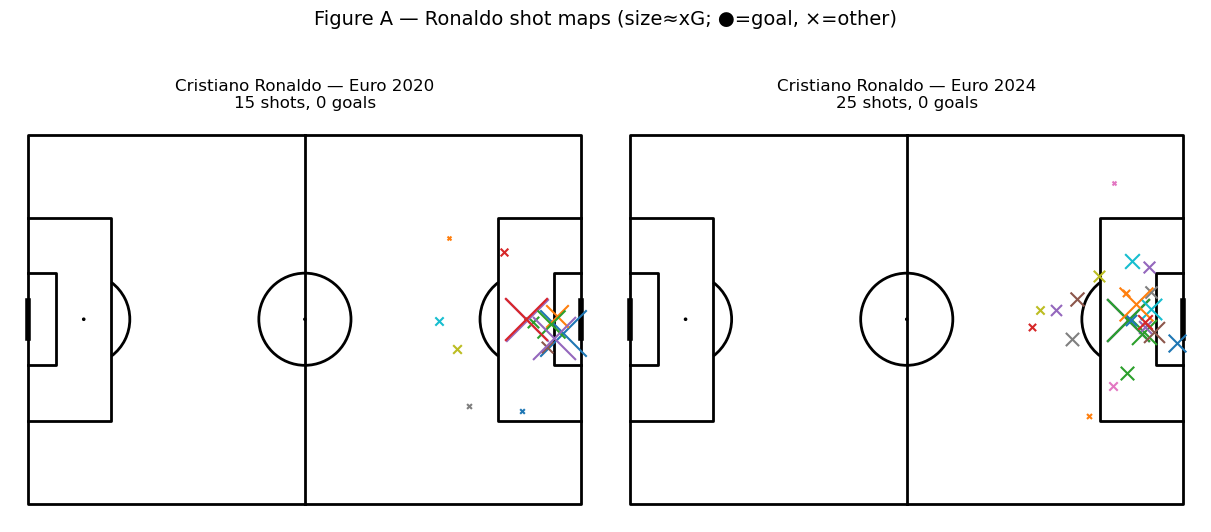

C:\Users\Rafallex\AppData\Local\Temp\ipykernel_12336\314106299.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax.scatter([float(ron_row["npxg_per90"])], [float(ron_row["shots_per90"])], s=400, marker="*", edgecolors="black")
C:\Users\Rafallex\AppData\Local\Temp\ipykernel_12336\314106299.py:52: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax.text(float(ron_row["npxg_per90"]), float(ron_row["shots_per90"]), f"  Ronaldo{label_suffix}", va="center")
C:\Users\Rafallex\AppData\Local\Temp\ipykernel_12336\314106299.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax.scatter([float(ron_row["npxg_per90"])], [float(ron_row["shots_per90"])], s=400, marker="*", edgecolors="black")
C:\Users\Rafall

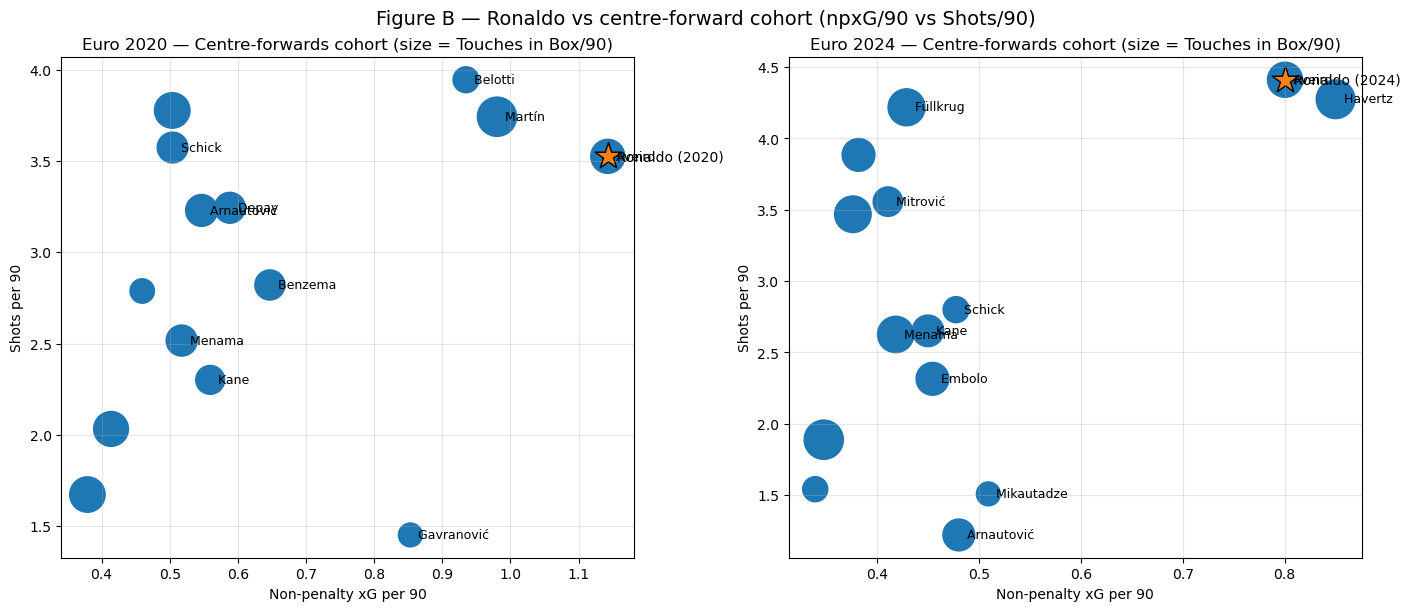

In [12]:
# ==== RUN: Ronaldo 2020 vs 2024 + CF cohort comparisons ====

COMP_ID, TEAM = 55, "Portugal"
SEASON_2020, SEASON_2024 = 43, 282

# 1) Build tournament-wide metrics
shots20_all, stats20_all = tournament_metrics(COMP_ID, SEASON_2020)
shots24_all, stats24_all = tournament_metrics(COMP_ID, SEASON_2024)

# 2) Extract Ronaldo only for each season
def pick_player(stats_df, q):
    m = stats_df[stats_df["player_name"].astype(str).str.contains(q, case=False, na=False)]
    return m.sort_values("minutes", ascending=False).head(1).copy()

ron20 = pick_player(stats20_all, "Cristiano Ronaldo")
ron24 = pick_player(stats24_all, "Cristiano Ronaldo")

print("Ronaldo 2020 per-90:", ron20[["minutes","shots_per90","npxg_per90","goals_per90"]].to_dict("records"))
print("Ronaldo 2024 per-90:", ron24[["minutes","shots_per90","npxg_per90","goals_per90"]].to_dict("records"))

# 3) Figure A — Ronaldo shot maps 2020 vs 2024
def plot_shotmap(ax, shots_df, name_query, title):
    pitch = Pitch(pitch_type="statsbomb", line_color="black")
    pitch.draw(ax=ax)
    sdf = shots_df[shots_df["player_name"].astype(str).str.contains(name_query, case=False, na=False)]
    goals = int(sdf["__is_goal__"].sum()) if not sdf.empty else 0
    for _, r in sdf.iterrows():
        size = 1200 * float(r.get("shot_statsbomb_xg", 0.05))
        if bool(r.get("__is_goal__", False)):
            pitch.scatter(r["x"], r["y"], s=size, marker="o", edgecolors="black", ax=ax)  # goal
        else:
            pitch.scatter(r["x"], r["y"], s=size, marker="x", ax=ax)                      # non-goal
    ax.set_title(f"{title}\n{len(sdf)} shots, {goals} goals", fontsize=12)

fig, ax = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
plot_shotmap(ax[0], shots20_all, "Cristiano Ronaldo", "Cristiano Ronaldo — Euro 2020")
plot_shotmap(ax[1], shots24_all, "Cristiano Ronaldo", "Cristiano Ronaldo — Euro 2024")
fig.suptitle("Figure A — Ronaldo shot maps (size≈xG; ●=goal, ×=other)", fontsize=14)
plt.show()

# 4) Figure B — Compare Ronaldo to other CFs in each Euro
# Try to get primary positions from tactics (if available); else heuristic
pos20 = primary_positions_from_tactics(COMP_ID, SEASON_2020)
pos24 = primary_positions_from_tactics(COMP_ID, SEASON_2024)

cf20 = pick_centre_forwards(stats20_all, pos_primary=pos20, min_minutes=180, top_n=14)
cf24 = pick_centre_forwards(stats24_all, pos_primary=pos24, min_minutes=180, top_n=14)

def add_marker_for_ronaldo(ax, ron_row, label_suffix=""):
    if ron_row.empty: return
    ax.scatter([float(ron_row["npxg_per90"])], [float(ron_row["shots_per90"])], s=400, marker="*", edgecolors="black")
    ax.text(float(ron_row["npxg_per90"]), float(ron_row["shots_per90"]), f"  Ronaldo{label_suffix}", va="center")

def cohort_scatter(ax, df, title):
    x = df["npxg_per90"].astype(float)
    y = df["shots_per90"].astype(float)
    size = 800 * (df["touches_in_box_per90"].astype(float) / (df["touches_in_box_per90"].max() or 1.0))
    ax.scatter(x, y, s=size)
    # label a few biggest by npxG/90
    lab = df.sort_values("npxg_per90", ascending=False).head(10)
    for _, r in lab.iterrows():
        nm = str(r["player_name"]).split()[-1]
        ax.text(r["npxg_per90"], r["shots_per90"], "  " + nm, va="center", fontsize=9)
    ax.set_xlabel("Non-penalty xG per 90")
    ax.set_ylabel("Shots per 90")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
cohort_scatter(axs[0], cf20, "Euro 2020 — Centre-forwards cohort (size = Touches in Box/90)")
add_marker_for_ronaldo(axs[0], ron20, " (2020)")

cohort_scatter(axs[1], cf24, "Euro 2024 — Centre-forwards cohort (size = Touches in Box/90)")
add_marker_for_ronaldo(axs[1], ron24, " (2024)")

fig.suptitle("Figure B — Ronaldo vs centre-forward cohort (npxG/90 vs Shots/90)", fontsize=14)
plt.show()


In [13]:
# --- RAW JSON PIPELINE (bypass Sbopen flatten) — Ronaldo Euro 2020 vs 2024 ---
import os, json, re, ast
import numpy as np
import pandas as pd

COMP_ID = 55
SEASON_IDS = {"Euro 2020": 43, "Euro 2024": 282}
TEAM_NAME = "Portugal"

# ---------- locate StatsBomb open-data /data root ----------
def find_data_root(start_dirs=(".", "/mnt/data")):
    for root in start_dirs:
        for dirpath, dirnames, filenames in os.walk(root):
            dn = set(name.lower() for name in dirnames)
            if "events" in dn and "matches" in dn:
                return dirpath
    raise FileNotFoundError("Couldn't find a StatsBomb 'data' folder with 'events' and 'matches' subfolders.")

DATA_ROOT = find_data_root()

EVENTS_DIR  = os.path.join(DATA_ROOT, "events")
MATCHES_DIR = os.path.join(DATA_ROOT, "matches")

# ---------- helpers ----------
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def get_portugal_match_ids_from_json(comp_id, season_id):
    mfile = os.path.join(MATCHES_DIR, str(comp_id), f"{season_id}.json")
    if not os.path.exists(mfile):
        raise FileNotFoundError(f"Matches file not found: {mfile}")
    matches = load_json(mfile)
    mids = []
    for m in matches:
        home = m.get("home_team", {}).get("home_team_name") or m.get("home_team", {}).get("name")
        away = m.get("away_team", {}).get("away_team_name") or m.get("away_team", {}).get("name")
        if home == TEAM_NAME or away == TEAM_NAME:
            mids.append(int(m["match_id"]))
    return mids

def minutes_from_events_json(events):
    """
    Compute minutes per player from Substitution events alone.
    Assumes 90' match (extra time not handled; fine for most Euro matches).
    """
    dur = 90
    mins = {}
    on, off = {}, {}
    for e in events:
        if e.get("type", {}).get("name") == "Substitution":
            minute = float(e.get("minute", 0))
            off_name = e.get("player", {}).get("name")
            on_name  = e.get("substitution", {}).get("replacement", {}).get("name")
            if off_name:
                off[off_name] = min(off.get(off_name, dur), minute)
            if on_name:
                on[on_name] = min(on.get(on_name, minute), minute)
    # who appeared at all (any event)
    ev_players = set()
    for e in events:
        nm = e.get("player", {}).get("name")
        if nm: ev_players.add(nm)
    starters = ev_players - set(on.keys())
    for p in starters: mins[p] = dur
    for p, m in off.items(): mins[p] = min(mins.get(p, dur), m)
    for p, m in on.items():  mins[p] = mins.get(p, 0.0) + max(0.0, dur - m)
    return mins

def collect_ronaldo_shots_and_minutes(match_ids):
    shots = []
    minutes_accum = {}
    for mid in match_ids:
        epath = os.path.join(EVENTS_DIR, f"{mid}.json")
        if not os.path.exists(epath):
            # some repos nest events: /events/{competition_id}/{season_id}/{match_id}.json — handle that too
            nested = os.path.join(EVENTS_DIR, str(COMP_ID), str(mid) + ".json")
            if os.path.exists(nested):
                epath = nested
            else:
                # fallback: walk for it once
                found = None
                for dirpath, dirnames, filenames in os.walk(EVENTS_DIR):
                    fpath = os.path.join(dirpath, f"{mid}.json")
                    if os.path.exists(fpath):
                        found = fpath
                        break
                if found:
                    epath = found
                else:
                    continue

        events = load_json(epath)

        # minutes
        m_map = minutes_from_events_json(events)
        for name, mins in m_map.items():
            minutes_accum[name] = minutes_accum.get(name, 0.0) + mins

        # shots by Ronaldo (team Portugal)
        for ev in events:
            if ev.get("type", {}).get("name") != "Shot": 
                continue
            team = ev.get("team", {}).get("name")
            if team != TEAM_NAME:
                continue
            player = (ev.get("player", {}) or {}).get("name", "")
            if "ronaldo" not in player.lower():
                continue
            loc = ev.get("location", [None, None])
            x = loc[0] if isinstance(loc, list) and len(loc) >= 2 else np.nan
            y = loc[1] if isinstance(loc, list) and len(loc) >= 2 else np.nan
            xg = ev.get("shot", {}).get("statsbomb_xg", np.nan)
            outcome = ev.get("shot", {}).get("outcome", {}).get("name")
            shots.append({"match_id": mid, "player_name": player, "x": x, "y": y, "xg": xg, "outcome": outcome})
    shots_df = pd.DataFrame(shots)
    return shots_df, minutes_accum

def per90_from(shots_df, minutes_map, player_query="Ronaldo"):
    if shots_df.empty:
        return {"minutes": 0.0, "shots_per90": np.nan, "xg_per90": np.nan, "goals_per90": np.nan, "goals": 0, "shots": 0, "xg": 0.0}
    sdf = shots_df[shots_df["player_name"].astype(str).str.contains(player_query, case=False, na=False)].copy()
    shots = len(sdf)
    goals = int((sdf["outcome"] == "Goal").sum())
    xg    = float(sdf["xg"].sum())
    # minutes: sum all entries in map that match query
    mins = 0.0
    for name, m in minutes_map.items():
        if player_query.lower() in str(name).lower():
            mins += float(m)
    if mins > 0:
        return {"minutes": mins,
                "shots_per90": shots * 90 / mins,
                "xg_per90":    xg    * 90 / mins,
                "goals_per90": goals * 90 / mins,
                "goals": goals, "shots": shots, "xg": xg}
    else:
        return {"minutes": 0.0, "shots_per90": np.nan, "xg_per90": np.nan, "goals_per90": np.nan, "goals": goals, "shots": shots, "xg": xg}

# ---------- run for both tournaments ----------
rows = []
debug = {}

for label, season_id in SEASON_IDS.items():
    mids = get_portugal_match_ids_from_json(COMP_ID, season_id)
    shots_df, minutes_map = collect_ronaldo_shots_and_minutes(mids)
    stats = per90_from(shots_df, minutes_map, player_query="Ronaldo")
    rows.append({"season": label, **stats})
    debug[label] = {"mids": mids, "shots_df": shots_df, "minutes_map": minutes_map}

out = pd.DataFrame(rows, columns=["season","minutes","shots_per90","xg_per90","goals_per90","goals","shots","xg"])
print("Cristiano Ronaldo — Euro 2020 vs 2024 (from RAW JSON):")
display(out)

# Sanity print: list of Ronaldo shot outcomes per season
for label in SEASON_IDS.keys():
    sdf = debug[label]["shots_df"]
    print(f"\n{label} — Ronaldo shot outcomes:", sdf["outcome"].dropna().tolist())


Cristiano Ronaldo — Euro 2020 vs 2024 (from RAW JSON):


,season,minutes,shots_per90,xg_per90,goals_per90,goals,shots,xg
0,Euro 2020,360.0,3.750000,1.215944,1.250000,5,15,4.863777
1,Euro 2024,425.0,5.294118,0.960631,0.423529,2,25,4.536313



Euro 2020 — Ronaldo shot outcomes: ['Goal', 'Off T', 'Saved', 'Off T', 'Goal', 'Off T', 'Goal', 'Saved', 'Blocked', 'Blocked', 'Blocked', 'Off T', 'Off T', 'Goal', 'Goal']

Euro 2024 — Ronaldo shot outcomes: ['Saved', 'Blocked', 'Off T', 'Goal', 'Saved', 'Off T', 'Off T', 'Saved', 'Off T', 'Saved', 'Saved to Post', 'Blocked', 'Goal', 'Saved', 'Blocked', 'Blocked', 'Saved', 'Off T', 'Off T', 'Wayward', 'Off T', 'Saved', 'Saved', 'Blocked', 'Saved']


In [16]:
# --- FIX: handle 'period' as int (or dict) and exclude shootouts, use 120' for ET ---

def period_id(ev):
    """Return the numeric period id from an event (handles int or dict)."""
    p = ev.get("period", None)
    if isinstance(p, dict):
        return p.get("id", None)
    try:
        return int(p) if p is not None else None
    except Exception:
        return None

def minutes_from_events_json(events):
    """
    Compute minutes per player for one match using Substitution events only.
    - Duration = 120 if ET (period 3 or 4 present), else 90.
    - Shootout (period 5) is ignored for minutes.
    """
    period_ids = {period_id(e) for e in events}
    dur = 120 if (3 in period_ids or 4 in period_ids) else 90

    mins = {}
    on, off = {}, {}

    for e in events:
        if e.get("type", {}).get("name") != "Substitution":
            continue
        m = float(e.get("minute", 0))
        off_name = (e.get("player", {}) or {}).get("name")
        on_name  = (e.get("substitution", {}) or {}).get("replacement", {}).get("name")
        if off_name:
            off[off_name] = min(off.get(off_name, dur), m)
        if on_name:
            on[on_name] = min(on.get(on_name, m), m)

    # players who appeared at all (any event)
    ev_players = set()
    for e in events:
        nm = (e.get("player", {}) or {}).get("name")
        if nm: ev_players.add(nm)

    starters = ev_players - set(on.keys())
    for p in starters: mins[p] = dur
    for p, m in off.items(): mins[p] = min(mins.get(p, dur), m)
    for p, m in on.items():  mins[p] = mins.get(p, 0.0) + max(0.0, dur - m)
    return mins

def collect_player_shots_and_minutes(comp_id, season_id, team_name, player_query):
    """
    Return (shots_df, minutes_map) for a given player on a given team in a competition season.
    - Excludes penalty shootout attempts (period == 5).
    """
    mids = team_match_ids(comp_id, season_id, team_name)
    shots = []
    minutes_accum = {}

    for mid in mids:
        # resolve events file path (flat / nested)
        epath = os.path.join(EVENTS_DIR, f"{mid}.json")
        if not os.path.exists(epath):
            nested = os.path.join(EVENTS_DIR, str(comp_id), f"{mid}.json")
            if os.path.exists(nested):
                epath = nested
            else:
                found = None
                for dirpath, _, filenames in os.walk(EVENTS_DIR):
                    if f"{mid}.json" in filenames:
                        found = os.path.join(dirpath, f"{mid}.json")
                        break
                if not found:
                    continue
                epath = found

        events = load_json(epath)

        # minutes for this match (ET-aware)
        m_map = minutes_from_events_json(events)
        for name, m in m_map.items():
            minutes_accum[name] = minutes_accum.get(name, 0.0) + float(m)

        # collect shots for this player (exclude shootouts)
        for ev in events:
            pid = period_id(ev)
            if pid == 5:            # penalty shootout -> skip
                continue
            if ev.get("type", {}).get("name") != "Shot":
                continue
            if ev.get("team", {}).get("name") != team_name:
                continue

            player = (ev.get("player", {}) or {}).get("name", "")
            if player_query.lower() not in player.lower():
                continue

            loc = ev.get("location", [None, None])
            x = loc[0] if isinstance(loc, list) and len(loc) >= 2 else np.nan
            y = loc[1] if isinstance(loc, list) and len(loc) >= 2 else np.nan
            xg = ev.get("shot", {}).get("statsbomb_xg", np.nan)
            outcome = ev.get("shot", {}).get("outcome", {}).get("name")
            shots.append({"match_id": mid, "player_name": player, "x": x, "y": y, "xg": xg, "outcome": outcome})

    shots_df = pd.DataFrame(shots)
    return shots_df, minutes_accum


In [17]:
rows = []
for label, season_id in SEASON_IDS.items():
    shots_df, minutes_map = collect_player_shots_and_minutes(COMP_ID, season_id, TEAM_NAME, PLAYER_QUERY)
    stats = per90_stats(shots_df, minutes_map, PLAYER_QUERY)
    rows.append({"season": label, **stats})

out = pd.DataFrame(rows, columns=["season","minutes","shots_per90","xg_per90","goals_per90","goals","shots","xg"])
display(out)


,season,minutes,shots_per90,xg_per90,goals_per90,goals,shots,xg
0,Euro 2020,360.0,3.750000,1.215944,1.25,5,15,4.863777
1,Euro 2024,485.0,4.268041,0.551006,0.00,0,23,2.969313


C:\Users\Rafallex\AppData\Local\Temp\ipykernel_12336\3824715197.py:56: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  xr = float(highlight_row["npxg_per90"])
C:\Users\Rafallex\AppData\Local\Temp\ipykernel_12336\3824715197.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  yr = float(highlight_row["shots_per90"])
C:\Users\Rafallex\AppData\Local\Temp\ipykernel_12336\3824715197.py:56: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  xr = float(highlight_row["npxg_per90"])
C:\Users\Rafallex\AppData\Local\Temp\ipykernel_12336\3824715197.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  yr = float(high

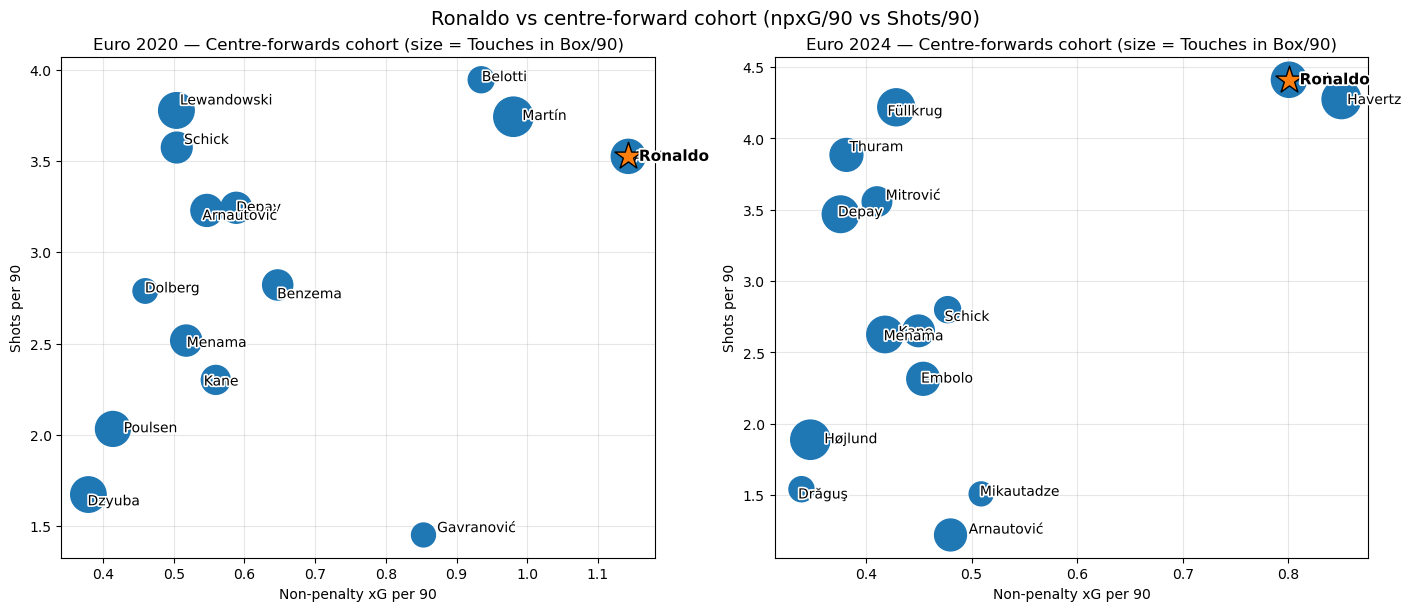

In [19]:
# --- Pretty, non-overlapping labels for Figure B ---
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe

# Try to use adjustText (better label repulsion). Falls back to a light jitter.
try:
    from adjustText import adjust_text
    _HAS_ADJUSTTEXT = True
except Exception:
    _HAS_ADJUSTTEXT = False

def surname(full):
    parts = str(full).split()
    return parts[-1] if parts else str(full)

def cohort_scatter_nice(ax, df, title, highlight_row=None, label_top_n=None):
    """
    df must have: player_name, npxg_per90, shots_per90, touches_in_box_per90
    highlight_row: a 1-row DataFrame/Series for Ronaldo marker.
    label_top_n: if set (e.g. 12), only label the top-N by npxg_per90 to reduce clutter.
    """
    plot_df = df.copy()
    if label_top_n is not None and label_top_n < len(plot_df):
        plot_df = plot_df.sort_values("npxg_per90", ascending=False).head(label_top_n)

    x = plot_df["npxg_per90"].astype(float).values
    y = plot_df["shots_per90"].astype(float).values
    # bubble size scaled within panel
    s = 800 * (plot_df["touches_in_box_per90"].astype(float) /
               (plot_df["touches_in_box_per90"].max() or 1.0))
    ax.scatter(x, y, s=s, zorder=2)

    # add labels with white outline for readability
    texts = []
    for xi, yi, name in zip(x, y, plot_df["player_name"]):
        t = ax.text(xi, yi, " " + surname(name), fontsize=10, va="center", zorder=3)
        t.set_path_effects([pe.withStroke(linewidth=2.4, foreground="white")])
        texts.append(t)

    if _HAS_ADJUSTTEXT:
        adjust_text(
            texts, ax=ax,
            expand_points=(1.2, 1.4), expand_text=(1.2, 1.4),
            arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.7)
        )
    else:
        # light jitter fallback to reduce obvious overlaps
        import numpy as np
        rng = np.random.default_rng(0)
        for t in texts:
            x0, y0 = t.get_position()
            t.set_position((x0 + rng.normal(0, 0.01), y0 + rng.normal(0, 0.04)))

    # Highlight Ronaldo
    if highlight_row is not None and not highlight_row.empty:
        xr = float(highlight_row["npxg_per90"])
        yr = float(highlight_row["shots_per90"])
        ax.scatter([xr], [yr], s=420, marker="*", color="#ff7f0e", edgecolors="black", zorder=5)
        tr = ax.text(xr, yr, "  Ronaldo", fontsize=11, weight="bold", va="center", zorder=6)
        tr.set_path_effects([pe.withStroke(linewidth=2.6, foreground="white")])

    ax.set_xlabel("Non-penalty xG per 90")
    ax.set_ylabel("Shots per 90")
    ax.set_title(title)
    ax.grid(alpha=0.3)

# ----- Replot Figure B with nicer labels -----
# Assumes you already have cf20, cf24 (centre-forward cohorts for each Euro)
# and ron20, ron24 (1-row DataFrames for Ronaldo) from earlier cells.
fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

cohort_scatter_nice(
    axs[0], cf20,
    "Euro 2020 — Centre-forwards cohort (size = Touches in Box/90)",
    highlight_row=ron20, label_top_n=None  # set to an int (e.g. 12) if you want fewer labels
)
cohort_scatter_nice(
    axs[1], cf24,
    "Euro 2024 — Centre-forwards cohort (size = Touches in Box/90)",
    highlight_row=ron24, label_top_n=None
)

fig.suptitle("Ronaldo vs centre-forward cohort (npxG/90 vs Shots/90)", fontsize=14)
plt.show()


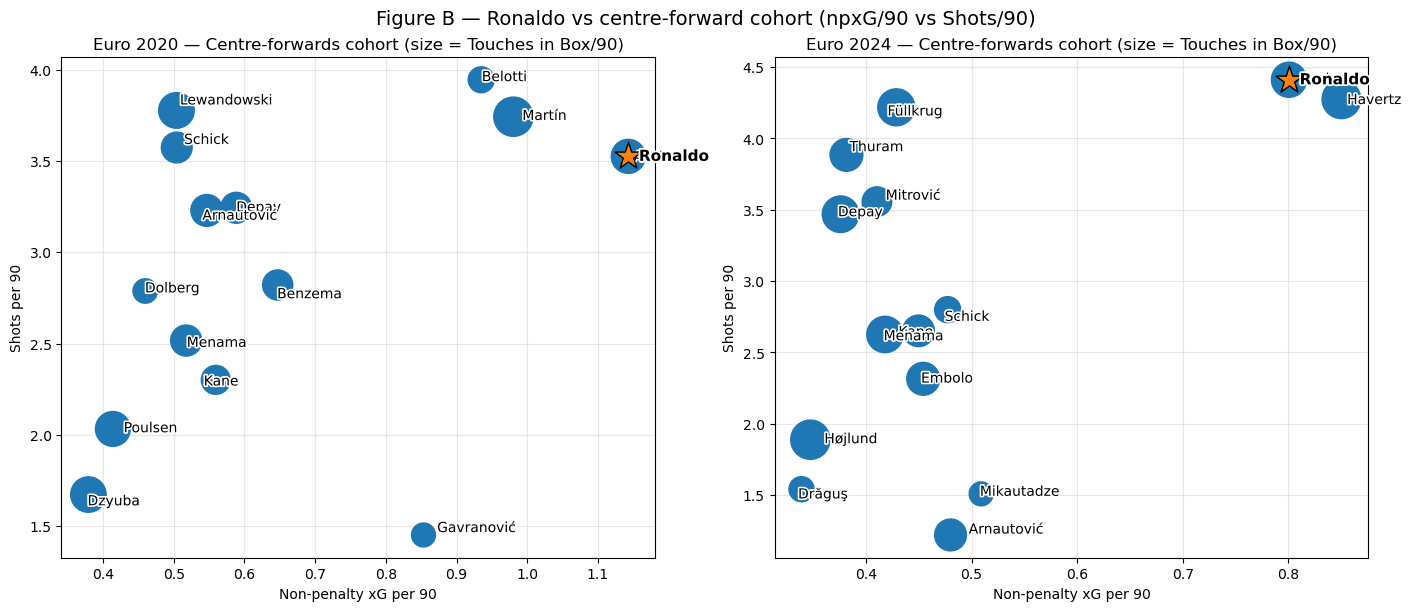

In [20]:
# ===== Pretty, non-overlapping labels + fixed Ronaldo highlight (no FutureWarning) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe

# Try to use adjustText for smart label repulsion; fall back to light jitter if not installed
try:
    from adjustText import adjust_text
    _HAS_ADJUSTTEXT = True
except Exception:
    _HAS_ADJUSTTEXT = False

def surname(full):
    parts = str(full).split()
    return parts[-1] if parts else str(full)

def cohort_scatter_nice(ax, df, title, highlight_row=None, label_top_n=None, fontsize=10):
    """
    df must contain columns: player_name, npxg_per90, shots_per90, touches_in_box_per90
    highlight_row: 1-row DataFrame or Series for the Ronaldo marker.
    label_top_n: int or None. If set, only label the top-N by npxG/90 to reduce clutter.
    """
    plot_df = df.copy()
    if label_top_n is not None and label_top_n < len(plot_df):
        plot_df = plot_df.sort_values("npxg_per90", ascending=False).head(label_top_n)

    x = plot_df["npxg_per90"].astype(float).values
    y = plot_df["shots_per90"].astype(float).values
    # bubble size scaled within panel
    size_scale = (plot_df["touches_in_box_per90"].astype(float) /
                  (plot_df["touches_in_box_per90"].max() or 1.0))
    s = 800 * size_scale
    ax.scatter(x, y, s=s, zorder=2)

    # Labels with white halo for readability
    texts = []
    for xi, yi, name in zip(x, y, plot_df["player_name"]):
        t = ax.text(xi, yi, " " + surname(name), fontsize=fontsize, va="center", zorder=3)
        t.set_path_effects([pe.withStroke(linewidth=2.4, foreground="white")])
        texts.append(t)

    if _HAS_ADJUSTTEXT:
        adjust_text(
            texts, ax=ax,
            expand_points=(1.2, 1.4), expand_text=(1.2, 1.4),
            arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.7)
        )
    else:
        # Light jitter fallback
        rng = np.random.default_rng(0)
        for t in texts:
            x0, y0 = t.get_position()
            t.set_position((x0 + rng.normal(0, 0.01), y0 + rng.normal(0, 0.04)))

    # Highlight Ronaldo (accept 1-row DataFrame or Series)
    if highlight_row is not None and not (isinstance(highlight_row, (pd.Series, pd.DataFrame)) and highlight_row.empty):
        r = highlight_row.iloc[0] if isinstance(highlight_row, pd.DataFrame) else highlight_row
        xr = float(pd.Series(r["npxg_per90"]).iloc[0])
        yr = float(pd.Series(r["shots_per90"]).iloc[0])
        ax.scatter([xr], [yr], s=420, marker="*", color="#ff7f0e",
                   edgecolors="black", zorder=5)
        tr = ax.text(xr, yr, "  Ronaldo", fontsize=fontsize+1, weight="bold",
                     va="center", zorder=6)
        tr.set_path_effects([pe.withStroke(linewidth=2.6, foreground="white")])

    ax.set_xlabel("Non-penalty xG per 90")
    ax.set_ylabel("Shots per 90")
    ax.set_title(title)
    ax.grid(alpha=0.3)

# ---- Replot both panels with nicer labels ----
fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

cohort_scatter_nice(
    axs[0], cf20,
    "Euro 2020 — Centre-forwards cohort (size = Touches in Box/90)",
    highlight_row=ron20, label_top_n=None, fontsize=10
)
cohort_scatter_nice(
    axs[1], cf24,
    "Euro 2024 — Centre-forwards cohort (size = Touches in Box/90)",
    highlight_row=ron24, label_top_n=None, fontsize=10
)

fig.suptitle("Figure B — Ronaldo vs centre-forward cohort (npxG/90 vs Shots/90)", fontsize=14)
plt.show()
